In [3]:
#5-30 라이브러리 호출
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torch.nn.functional as F
import torch.nn as nn
from torchvision.transforms import ToTensor
import torchvision
import torchvision.transforms as transform
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else 'cpu')

In [20]:
#5-31 설명 가능한 네트워크 생성 (신뢰성을 위한)
#13개의 합성곱층과 두개의 완전연결층으로 구성된 네트워크, bias : 입력고 상관없이 더해지는 값 (y = wx + b(bias))
class XAI(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(XAI, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True), # inplace=True : 기존 데이터를 연산의 결과값으로 대체
            nn.Dropout(0.3),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential( # 정답을 출력하는 부분
            nn.Linear(512, 512, bias=False), #완전연결층 1
            nn.Dropout(0.5),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes) #완전연결층 2
        )

    def forward(self, x): # 실제 계산 부
        x = self.features(x)
        x = x.view(-1, 512)
        x = self.classifier(x)
        #return F.log_softmax(x) #1
        return F.log_softmax(x, dim=1) #모델 출력 모양이 (배치 수, 클래스 수)여서 왼 -> 오 방향으로 계산

# 1. F.log_softmax() : 로그 소프트맥스 
# 신경망 말단의 결괏값들을 확률 개념으로 해석하기 위해 소프트맥스(softmax) 함수의 결과에 log를 취한 연산 
# 소프트 맥스를 사용하지 않고 로그 소프트맥스를 사용하는 이유 : 소프트맥스는 기울기 소멸 문제(vanishing gradient problem)에 취약하기 때문

In [21]:
#5-32 모델의 객체화
model = XAI() #model이라는 이름의 객체 생성
model.to(device) #model의 장치(CPU 혹은 GPU에 할당)
model.eval() #테스트 데이터에 대한 모델 평가 용도로 사용

XAI(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU(inplace=True

In [22]:
#5-33 특성 맵을 확인하기 위한 클래스 정의
#특성 맵의 결과를 확인할 수 있는 함수 정의
#특성 맵 : 합성곱층 입력 이미지와 필터를 연산하여 얻은 결과 -> 입력과 출력을 알 수 있다면 특성 맵에 대한 값들을 확인 가능
class LayerActivations:
    features = []
    def __init__(self, model, layer_num):
        self.hook = model[layer_num].register_forward_hook(self.hook_fn) #1

    def hook_fn(self, module, input, output):
        self.features = output.detach().numpy()

    def remove(self): # hook 삭제
        self.hook.remove()


#1. pytorch : 매 계층마다 print 문을 사용하지 않더라도 hook 기능을 사용하여 각 계층의 활성화 함수 및 기울기 값 확인 가능
# register_forward_hook 목적 : 순전파 중에 각 네트워크 모듈의 입력 및 출력 값을 가져오는 것 

torch.Size([1, 3, 100, 100])


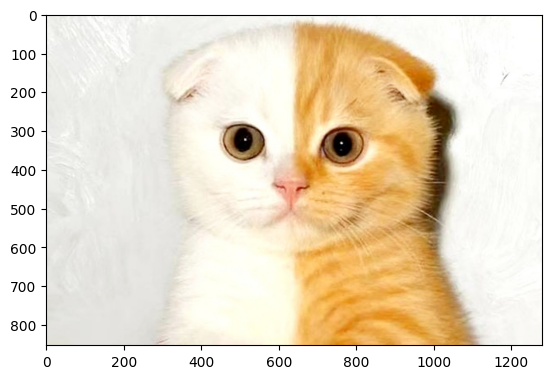

In [23]:
#5-34 이미지 호출
img = cv2.imread("./data/cat.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) #OpenCV의 경우 BGR을 많이 썼어서 색이 변환되어 나타나기때문에 지정 
plt.imshow(img)

img = cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR) #1
img = ToTensor()(img).unsqueeze(0) #2
print(img.shape)

# 1. cv2.resize(img, (100, 100), interpolation=cv2.INTER_LINEAR) : 이미지 크기 변경할 때 사용
# 첫번째 파라미터(ex. img) : 변경할 이미지 파일
# 두번째 파라미터(ex. (100, 100) :  변경될 이미지 크기를(너비, 높이)로 지정
# interpolation : 보간법
# 보간법 : 이미지상에 존재하는 픽셀 데이터(x, y)들에 대해 근사 함수 f(x, y)를 적용하여 새로운 픽셀 값을 구하는 것 *(부가설명) 알고 있는 값들 사이의 빈칸을 추측해서 채우는 방법
# -> 이미지 크기를 변경할 경우 변형된 이미지의 픽셀을 추정해서 값을 할당 
# -> 이미지 비율을 변경하면 존재하지 않은 영역에 새로운 픽셀 값을 매핑하거나 존재하는 픽셀들을 압축헤서 새로운 값 할당

# 2. ToTensor()(img).unsqueeze(0)에서 사용된 unsqueeze() : 1차원 데이터를 생성하는 함수
# -> 이미지 데이터를 텐서로 변환 -> 1차원으로 변경 -> 몇번째 인덱스에 1차원을 넣을지, 합성곱층은 4차원 데이터를 넣어야함
# img                          # (100, 100, 3)      높이, 너비, 채널  ← OpenCV 형식
# ToTensor()(img)              # (3, 100, 100)      채널, 높이, 너비  ← PyTorch 형식
# ToTensor()(img).unsqueeze(0) # (1, 3, 100, 100)   배치, 채널, 높이, 너비

In [24]:
#5-35 (0) : Conv2d 특성 맵 확인
result = LayerActivations(model.features, 0) #0번째 Conv2d 특성 맵 확인

model(img)
activations = result.features

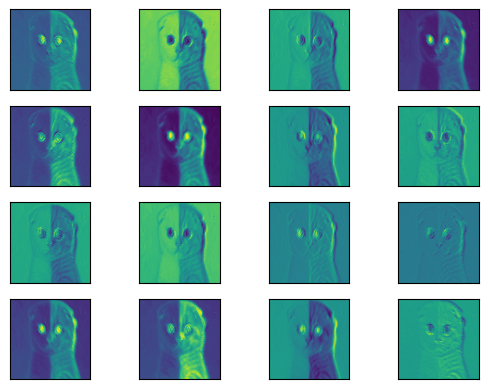

<Figure size 1200x800 with 0 Axes>

In [25]:
# 5-36 특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
        
plt.show()

In [26]:
#5-37 20번째 계층에 대한 특성 맵
result = LayerActivations(model.features, 20) #20번째 Conv2d 특성 맵 획ㅇ;ㄴ

model(img)
activations =result.features

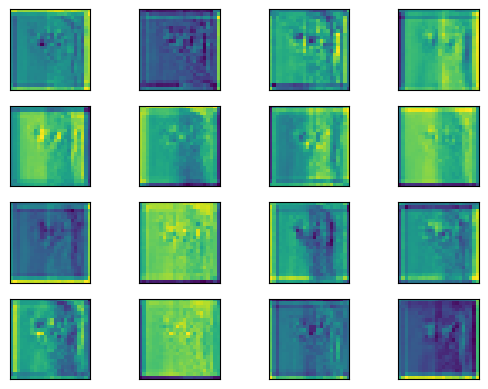

<Figure size 1200x800 with 0 Axes>

In [27]:
#5-38 특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
        
plt.show()

In [28]:
#5-39 40번째 계층에 대한 특성 맵
result = LayerActivations(model.features, 40) #40번째 Conv2d 특성 맵 획ㅇ;ㄴ

model(img)
activations =result.features

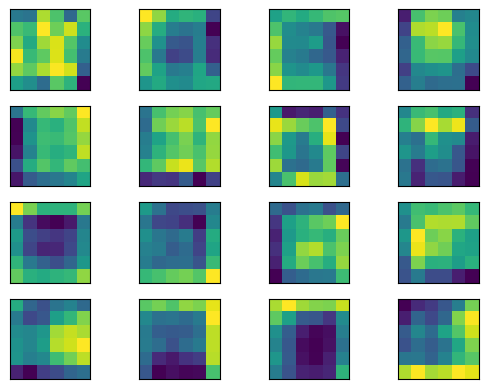

<Figure size 1200x800 with 0 Axes>

In [29]:
#5-40 특성 맵 확인
fig, axes = plt.subplots(4, 4)
fig = plt.figure(figsize=(12, 8))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for row in range(4):
    for column in range(4):
        axis = axes[row][column]
        axis.get_xaxis().set_ticks([])
        axis.get_yaxis().set_ticks([])
        axis.imshow(activations[0][row*10+column])
        
plt.show()

#(결론) 출력층에 가까울수록 원래 형태는 찾아볼 수 없고 이미지 특징만 전달되는 것을 확인할 수 있음 